<a href="https://colab.research.google.com/github/elhazsow/pytorch0-workshop/blob/main/pytorch0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np

In [2]:
np1=np.random.rand(3,4)
np1

array([[0.28841655, 0.68298392, 0.72633219, 0.54915888],
       [0.36155046, 0.27387846, 0.6186234 , 0.63111133],
       [0.75322369, 0.47270924, 0.3540915 , 0.07365164]])

In [3]:
np1.dtype

dtype('float64')

In [4]:
#Tensor

##TENSEUR

In [5]:
tensor_2d=torch.randn(3,4)
tensor_2d

tensor([[ 0.3074, -0.8607, -0.3820,  0.1634],
        [ 1.0444, -0.3457, -1.0293, -0.7384],
        [ 0.1509,  0.1241, -0.7881, -0.6194]])

In [6]:
tensor_3d=torch.zeros(2,3,4)
tensor_3d

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [7]:
my_torch = torch.arange(10)
my_torch

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

###reshape and view

In [8]:
my_torch=my_torch.reshape(2,5)
my_torch

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [9]:
my_torch2= torch.arange(15)
my_torch2

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [10]:
my_torch2.reshape(3,-1)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]])

### Difference Between `view()` and `reshape()` in PyTorch

While both `view()` and `reshape()` are used to change the shape of a tensor, they behave differently under the hood regarding memory layouts:

* **`view()`**:
  * It returns a new tensor that shares the **same underlying data** with the original tensor.
  * It requires the tensor to be **contiguous** in memory. If the tensor is not contiguous (for example, after a transpose operation), calling `view()` will raise a `RuntimeError`. You would have to call `.contiguous().view()` to make it work.

* **`reshape()`**:
  * It can handle both contiguous and non-contiguous tensors.
  * If the tensor is contiguous, `reshape()` behaves exactly like `view()` and returns a view sharing the same data.
  * If the tensor is not contiguous, `reshape()` will **automatically copy** the data into a contiguous memory block behind the scenes and return a new tensor with its own memory copy.

In [11]:
# 1. Demonstrating view() and reshape() on a contiguous tensor
original = torch.arange(10)

# Both work and share the same memory
view_tensor = original.view(2, 5)
reshape_tensor = original.reshape(2, 5)

# Modifying the original tensor affects both views
original[0] = 99
print("Modified Original:", original)
print("view_tensor:", view_tensor)
print("reshape_tensor:", reshape_tensor)

Modified Original: tensor([99,  1,  2,  3,  4,  5,  6,  7,  8,  9])
view_tensor: tensor([[99,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9]])
reshape_tensor: tensor([[99,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9]])


In [12]:
# 2. Demonstrating what happens on a non-contiguous tensor (e.g., after transpose)
base_tensor = torch.randn(3, 4)
transposed = base_tensor.t() # Transposing makes the tensor non-contiguous

print("Is transposed contiguous?:", transposed.is_contiguous())

# Try reshape (works automatically by making a copy behind the scenes)
try:
    reshaped_non_contig = transposed.reshape(12)
    print("reshape() succeeded on non-contiguous tensor.")
except Exception as e:
    print("reshape() failed:", e)

# Try view (will fail unless we explicitly make it contiguous first)
try:
    view_non_contig = transposed.view(12)
    print("view() succeeded on non-contiguous tensor.")
except RuntimeError as e:
    print("view() failed as expected:", e)

Is transposed contiguous?: False
reshape() succeeded on non-contiguous tensor.
view() failed as expected: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.


NN.Module

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math


# Create Tensors to hold input and outputs.
x = torch.linspace(-10, 10, 500).reshape(500, 1)
y = 3*x+2 +torch.randn(x.size())
y_true=3*x+2

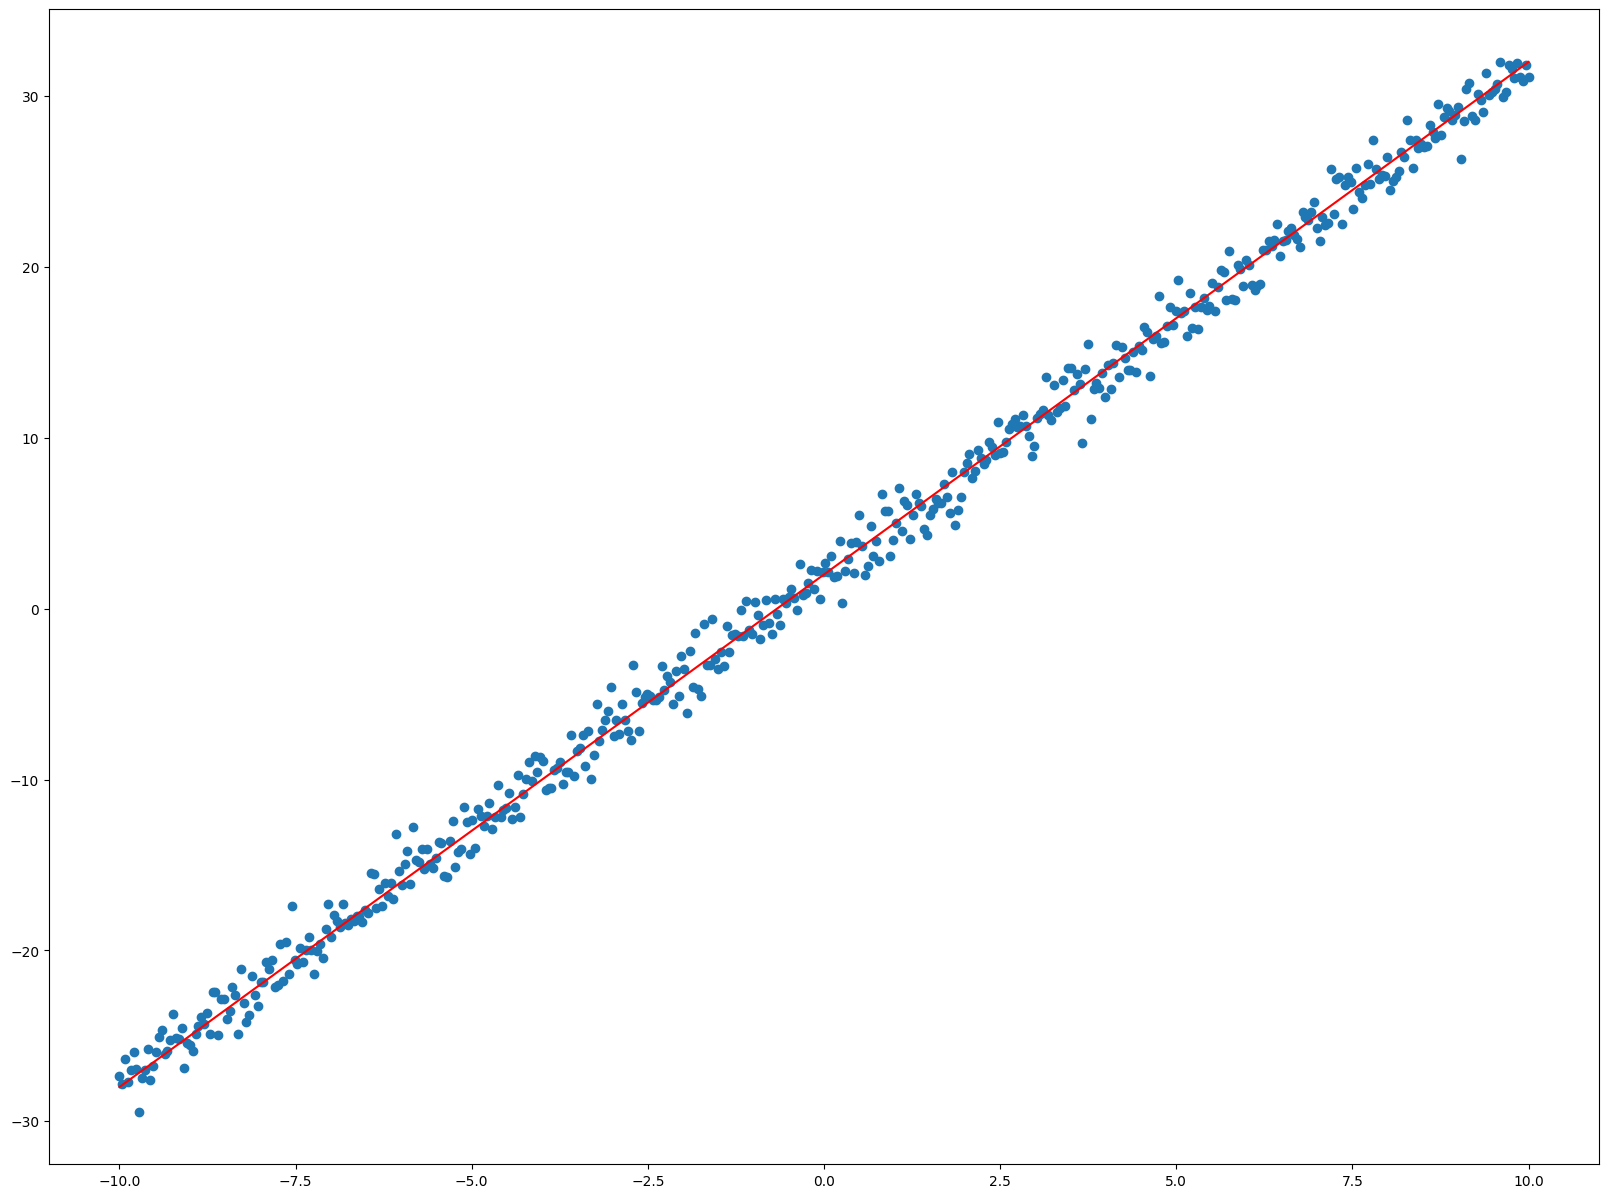

In [14]:
fig= plt.figure(figsize=(20,15))
plt.plot(x, y_true,color='red')
plt.scatter(x, y)
plt.show()

In [15]:
# Use the nn package to define our model as a sequence of layers. nn.Sequential
# is a Module which contains other Modules, and applies them in sequence to
# produce its output. The Linear Module computes output from input using a
# linear function, and holds internal Tensors for its weight and bias.
model = torch.nn.Sequential(
    torch.nn.Linear(1, 1)
)

# The nn package also contains definitions of popular loss functions; in this
# case we will use Mean Squared Error (MSE) as our loss function.
loss_fn = torch.nn.MSELoss(reduction='sum')

In [16]:
learning_rate = 1e-6
losses=[]
for t in range(2000):
   # Forward pass: compute predicted y by passing x to the model. Module objects
    # override the __call__ operator so you can call them like functions. When
    # doing so you pass a Tensor of input data to the Module and it produces
    # a Tensor of output data.
    y_pred = model(x)

    # Compute and print loss. We pass Tensors containing the predicted and true
    # values of y, and the loss function returns a Tensor containing the
    # loss.
    loss = loss_fn(y_pred, y)
    if t % 10 == 0:
        losses.append((t, loss.item()))

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Backward pass: compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Tensors with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    loss.backward()

    # Update the weights using gradient descent. Each parameter is a Tensor, so
    # we can access its gradients like we did before.
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad



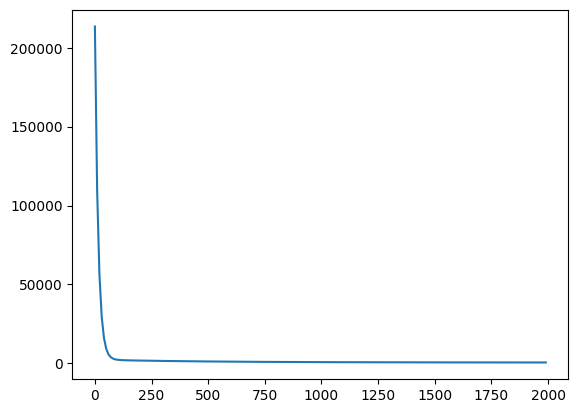

In [17]:
losses=np.array(losses)
plt.plot(losses[:,0],losses[:,1])
plt.show()

In [18]:
# You can access the first layer of `model` like accessing the first item of a list
linear_layer = model[0]

# For linear layer, its parameters are stored as `weight` and `bias`.
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight.item()} x ')

Result: y = 1.7554025650024414 + 2.9786875247955322 x 


## Sinus(x)

In [19]:
x_sin=torch.linspace(-math.pi, math.pi, 1000)

y_sin = torch.sin(x_sin)

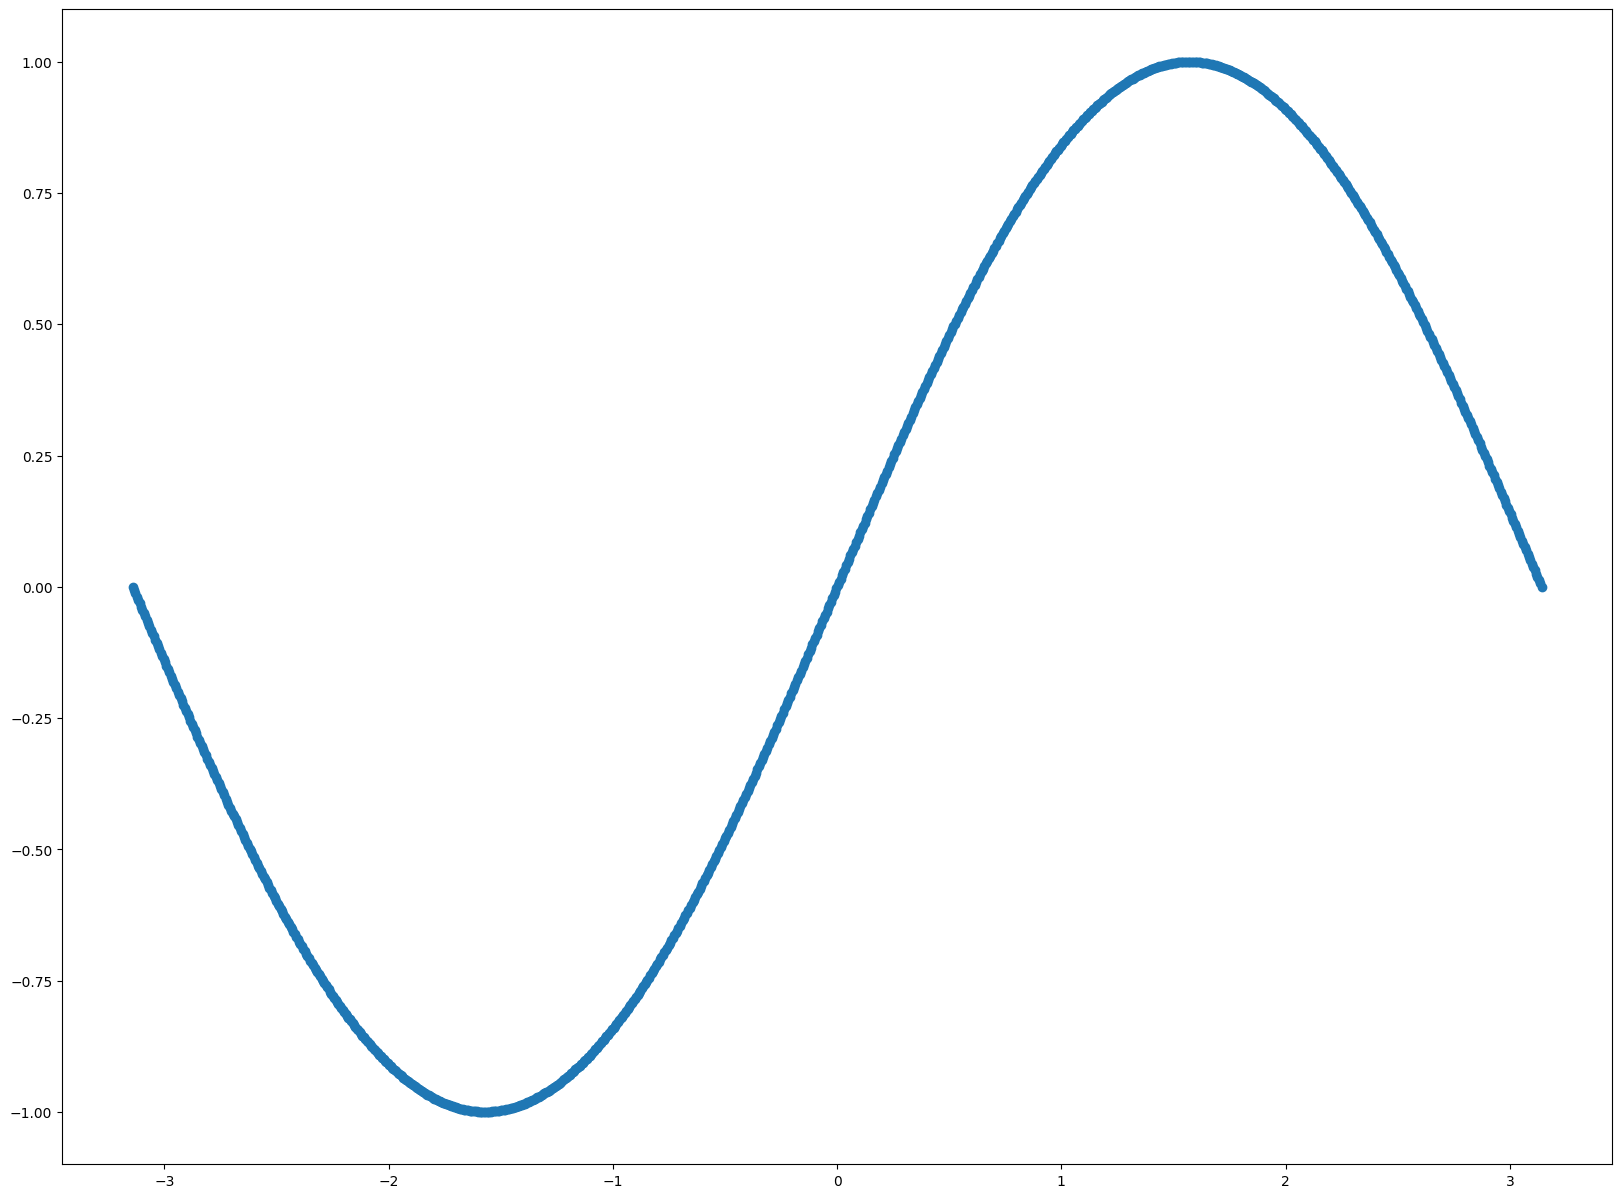

In [20]:
fig= plt.figure(figsize=(20,15))
# plt.plot(x, y_true,color='red')
plt.scatter(x_sin, y_sin)
plt.show()

In [21]:
# For this example, the output y is a linear function of (x, x^2, x^3), so
# we can consider it as a linear layer neural network. Let's prepare the
# tensor (x, x^2, x^3).
p = torch.tensor([1, 2, 3])
xx = x_sin.unsqueeze(-1).pow(p)

In [22]:
xx.shape

torch.Size([1000, 3])

In [46]:

# to match the shape of `y`.
model = torch.nn.Sequential(
    torch.nn.Linear(3, 1),
    torch.nn.Flatten(0, 1)
)


loss_fn = torch.nn.MSELoss(reduction='sum')

In [47]:
learning_rate = 1e-3
losses_=[]
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)
for t in range(2000):
  #forword pass
  y_pred = model(xx)
  #loss
  loss = loss_fn(y_pred, y_sin)
  if t % 10 == 0:
        losses_.append((t, loss.item()))

  # Zero the gradients before running the backward pass.
  model.zero_grad()

  # all learnable parameters in the model.
  loss.backward()

  # Calling the step function on an Optimizer makes an update to its
  # parameters
  optimizer.step()


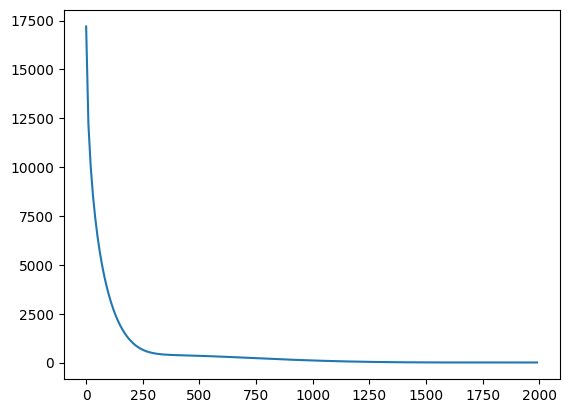

In [48]:
losses_=np.array(losses_)
plt.plot(losses_[:,0],losses_[:,1])
plt.show()

In [49]:
linear_layer = model[0]
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2 + {linear_layer.weight[:, 2].item()} x^3')

Result: y = -0.0005011743633076549 + 0.8569685220718384 x + -0.000501175585668534 x^2 + -0.09269671887159348 x^3


In [50]:
y_model = linear_layer.bias.item() + linear_layer.weight[:, 0].item()*x_sin + linear_layer.weight[:, 1].item()*x_sin**2 + linear_layer.weight[:, 2].item()*x_sin**3

In [51]:
y_model.shape

torch.Size([1000])

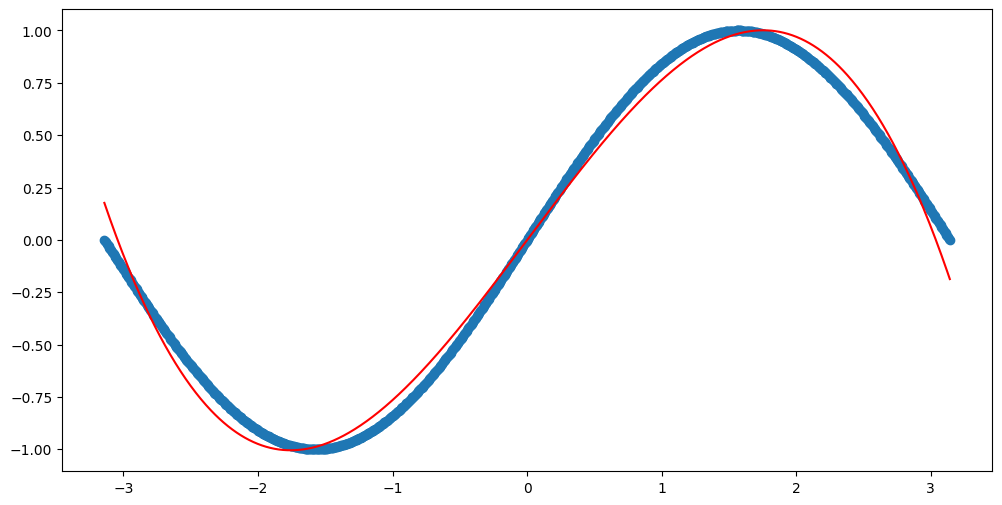

In [52]:

fig= plt.figure(figsize=(12,6))
plt.plot(x_sin, y_model,color='red')
plt.scatter(x_sin, y_sin)
plt.show()

## MNIST

In [30]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [31]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.5MB/s]


In [32]:
# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

In [33]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [34]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [35]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


# Creating Models

In [36]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [37]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


# Optimizing the Model Parameters

In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [39]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [40]:
# We also check the model’s performance against the test dataset to ensure it is learning
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [41]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.292952  [   64/60000]
loss: 2.289697  [ 6464/60000]
loss: 2.269849  [12864/60000]
loss: 2.261104  [19264/60000]
loss: 2.259246  [25664/60000]
loss: 2.224720  [32064/60000]
loss: 2.223956  [38464/60000]
loss: 2.195947  [44864/60000]
loss: 2.182657  [51264/60000]
loss: 2.145796  [57664/60000]
Test Error: 
 Accuracy: 48.5%, Avg loss: 2.150770 

Epoch 2
-------------------------------
loss: 2.157546  [   64/60000]
loss: 2.155305  [ 6464/60000]
loss: 2.096980  [12864/60000]
loss: 2.103142  [19264/60000]
loss: 2.066913  [25664/60000]
loss: 2.003760  [32064/60000]
loss: 2.020281  [38464/60000]
loss: 1.946535  [44864/60000]
loss: 1.942913  [51264/60000]
loss: 1.862227  [57664/60000]
Test Error: 
 Accuracy: 58.4%, Avg loss: 1.873449 

Epoch 3
-------------------------------
loss: 1.906309  [   64/60000]
loss: 1.882537  [ 6464/60000]
loss: 1.768097  [12864/60000]
loss: 1.796741  [19264/60000]
loss: 1.697636  [25664/60000]
loss: 1.654008  [32064/600

# Saving Models

In [42]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


# Loading Models

In [43]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [44]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


# UNET

In [45]:
#Unet architecture
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Convolution 3x3 -> BatchNorm -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()

        # Encodeur (Descente)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Décodeur (Remontée) + Upsampling
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512) # 512 (Up) + 512 (Skip) = 1024 en entrée

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64)

        # Couche de sortie (1x1 conv pour ramener au nombre de classes souhaité)
        self.outc = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Passage dans l'encodeur & stockage des récepteurs pour les Skip Connections
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x_bot = self.bottleneck(x4)

        # Remontée avec concaténation (dim=1 correspond à l'axe des canaux)
        x = self.up1(x_bot)
        x = torch.cat([x, x4], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return logits

# Test de vérification des dimensions
if __name__ == "__main__":
    x = torch.randn((2, 3, 256, 256)) # Batch de 2 images RGB 256x256
    model = UNet(in_channels=3, num_classes=1)
    output = model(x)
    print("Forme de l'entrée :", x.shape)
    print("Forme de la sortie :", output.shape) # Attendu : [2, 1, 256, 256]

Forme de l'entrée : torch.Size([2, 3, 256, 256])
Forme de la sortie : torch.Size([2, 1, 256, 256])
